# Eksperimen Machine Learning - Dataset Titanic
**Nama:** Dwi Saktya Hari Aditya  
**Dataset:** Titanic - Machine Learning from Disaster  
**Sumber:** [Kaggle Titanic Dataset](https://www.kaggle.com/c/titanic)  
**Task:** Binary Classification (Survived / Not Survived)

## 1. Perkenalan Dataset

Dataset Titanic berisi data penumpang kapal RMS Titanic yang tenggelam pada tahun 1912. Tujuan dari eksperimen ini adalah memprediksi apakah seorang penumpang selamat atau tidak berdasarkan fitur-fitur seperti usia, jenis kelamin, kelas kabin, dan lainnya.

**Fitur utama:**
- `Survived` — target (0 = tidak selamat, 1 = selamat)
- `Pclass` — kelas tiket (1, 2, 3)
- `Sex` — jenis kelamin
- `Age` — usia penumpang
- `SibSp` — jumlah saudara/pasangan di kapal
- `Parch` — jumlah orang tua/anak di kapal
- `Fare` — harga tiket
- `Embarked` — pelabuhan keberangkatan (C, Q, S)

## 2. Import Library

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## 3. Memuat Dataset

In [6]:
# Load dataset Titanic dari seaborn (built-in, tidak perlu upload manual)
df = sns.load_dataset('titanic')

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'\nJumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')

Dataset berhasil dimuat!
Shape: (891, 15)

Jumlah baris  : 891
Jumlah kolom  : 15


In [7]:
# Cek beberapa baris awal
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
# Statistik deskriptif
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis (EDA)

In [10]:
# 4.1 Cek Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

             Missing Values  Persentase (%)
age                     177           19.87
embarked                  2            0.22
deck                    688           77.22
embark_town               2            0.22


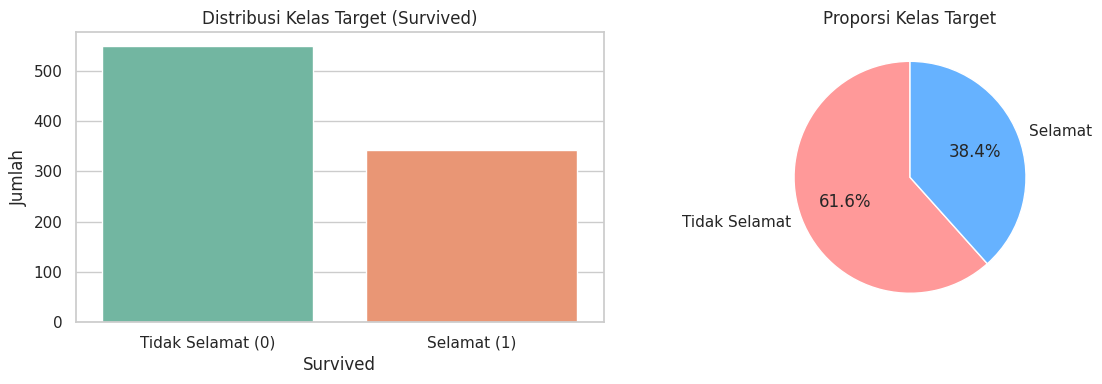


Distribusi:
survived
0    549
1    342
Name: count, dtype: int64


In [11]:
# 4.2 Distribusi Target (Survived)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='survived', palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Kelas Target (Survived)')
axes[0].set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'])
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Jumlah')

# Pie chart
survived_counts = df['survived'].value_counts()
axes[1].pie(survived_counts, labels=['Tidak Selamat', 'Selamat'],
            autopct='%1.1f%%', colors=['#ff9999', '#66b2ff'], startangle=90)
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.show()

print(f'\nDistribusi:\n{df["survived"].value_counts()}')

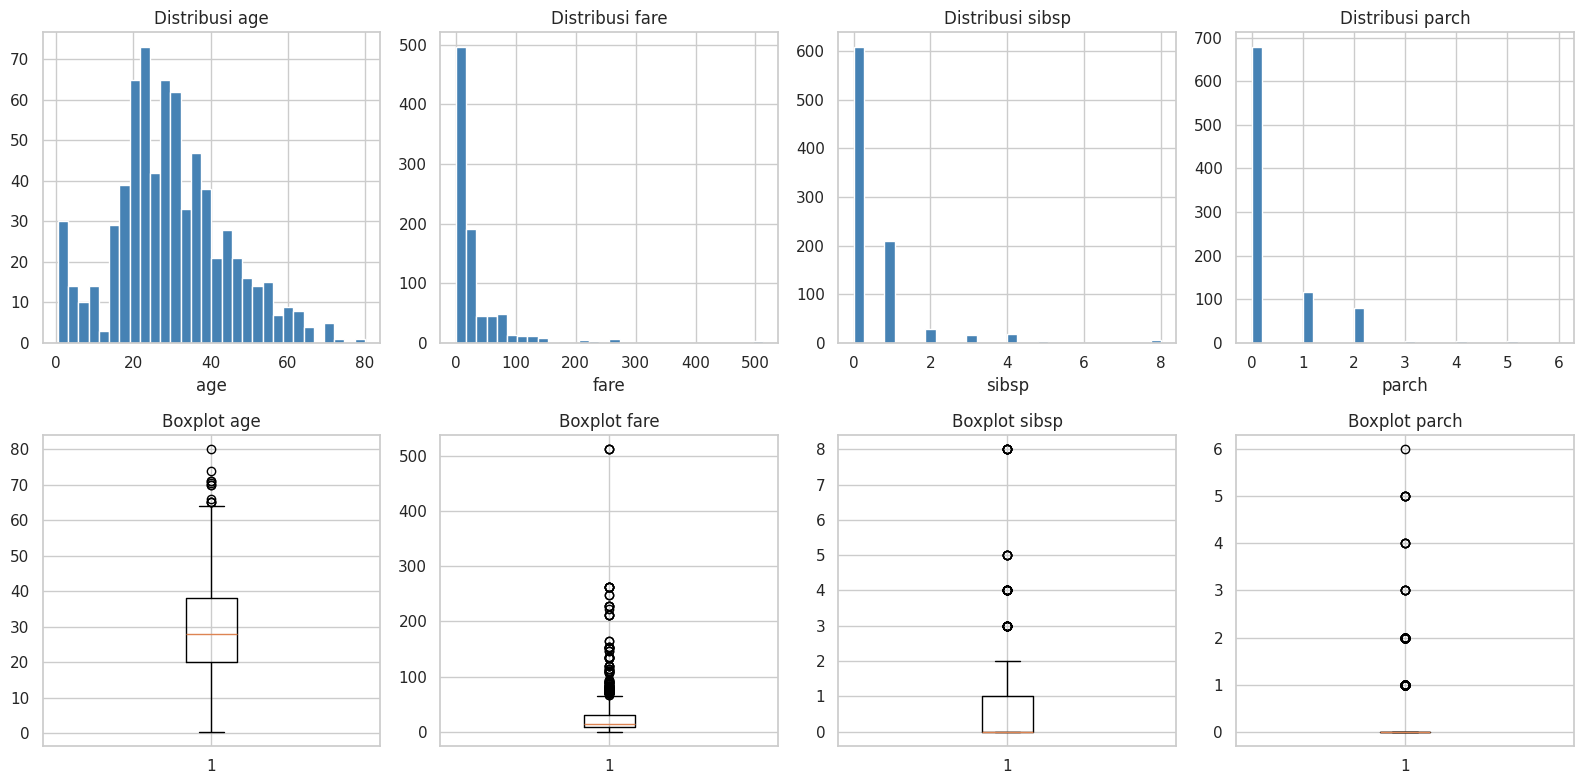

In [12]:
# 4.3 Distribusi Fitur Numerik
num_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'Distribusi {col}')
    axes[0, i].set_xlabel(col)

    # Boxplot
    axes[1, i].boxplot(df[col].dropna())
    axes[1, i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

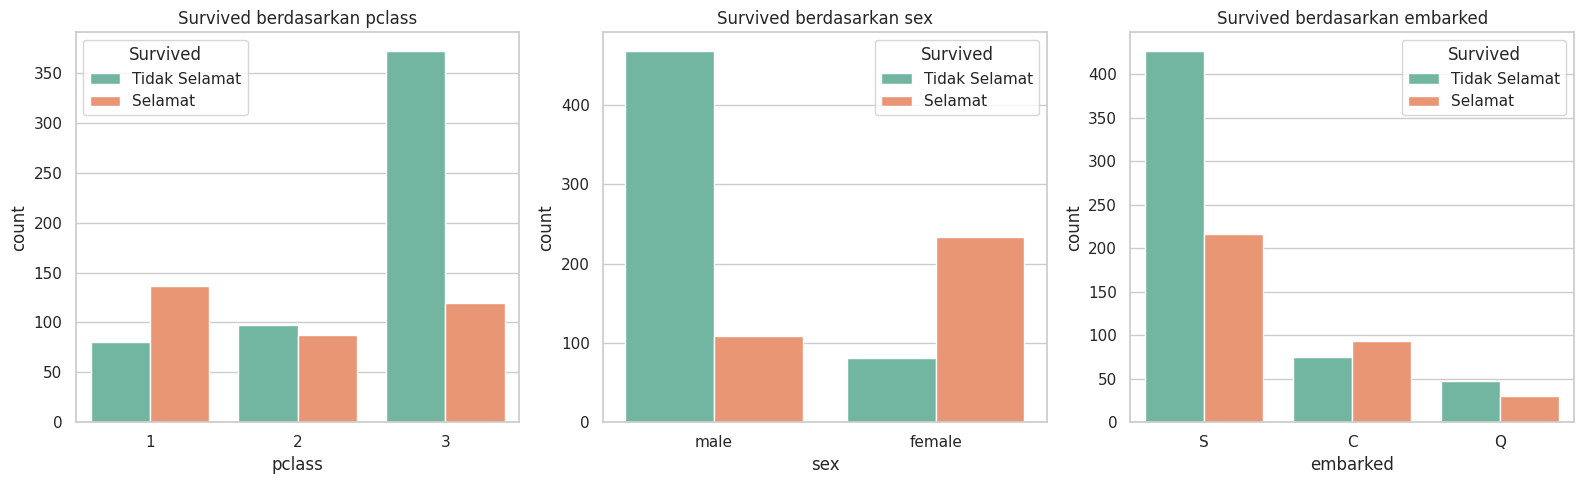

In [13]:
# 4.4 Analisis Fitur Kategorikal terhadap Target
cat_cols = ['pclass', 'sex', 'embarked']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='survived', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Survived berdasarkan {col}')
    axes[i].legend(title='Survived', labels=['Tidak Selamat', 'Selamat'])

plt.tight_layout()
plt.show()

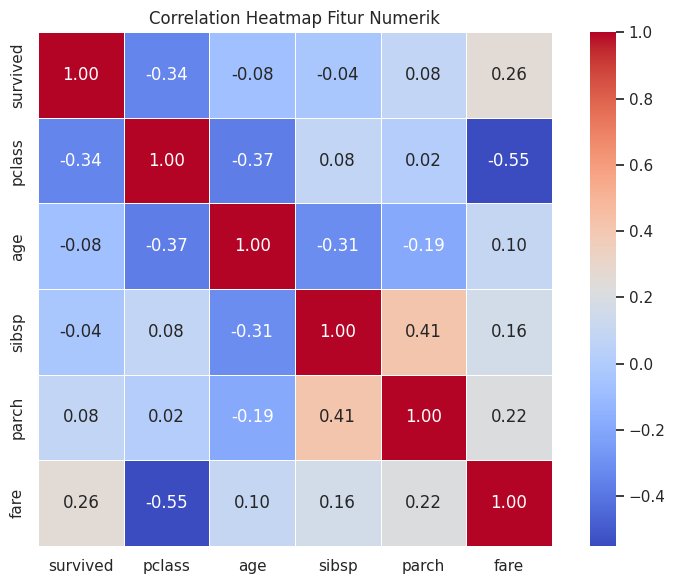

In [14]:
# 4.5 Correlation Heatmap
# Encode dulu untuk heatmap
df_temp = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].copy()

plt.figure(figsize=(8, 6))
corr = df_temp.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap Fitur Numerik')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [15]:
# 5.1 Pilih Fitur yang Relevan
# Kolom redundan (deck, embark_town, alive, who, adult_male, alone) dihapus
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df_clean = df[features].copy()

print('Kolom yang digunakan:')
print(df_clean.columns.tolist())
print(f'\nShape: {df_clean.shape}')

Kolom yang digunakan:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']

Shape: (891, 8)


In [16]:
# 5.2 Menangani Missing Values
print('Missing values sebelum:')
print(df_clean.isnull().sum())

# Age: isi dengan median
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

# Embarked: isi dengan modus
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

print('\nMissing values setelah:')
print(df_clean.isnull().sum())

Missing values sebelum:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Missing values setelah:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [17]:
# 5.3 Menghapus Data Duplikat
print(f'Jumlah duplikat: {df_clean.duplicated().sum()}')
df_clean.drop_duplicates(inplace=True)
print(f'Shape setelah drop duplikat: {df_clean.shape}')

Jumlah duplikat: 116
Shape setelah drop duplikat: (775, 8)


In [18]:
# 5.4 Encoding Data Kategorikal
le = LabelEncoder()

# Encode 'sex': male=1, female=0
df_clean['sex'] = le.fit_transform(df_clean['sex'])

# Encode 'embarked': C=0, Q=1, S=2
df_clean['embarked'] = le.fit_transform(df_clean['embarked'])

print('Data setelah encoding:')
df_clean.head()

Data setelah encoding:


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


In [19]:
# 5.5 Deteksi dan Penanganan Outlier (IQR Method pada 'fare')
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df_clean['fare'] < lower) | (df_clean['fare'] > upper)).sum()
print(f'Jumlah outlier pada fare: {outlier_count}')

# Cap outlier (clipping)
df_clean['fare'] = df_clean['fare'].clip(lower=lower, upper=upper)
print(f'Outlier setelah clipping: {((df_clean["fare"] < lower) | (df_clean["fare"] > upper)).sum()}')

Jumlah outlier pada fare: 102
Outlier setelah clipping: 0


In [20]:
# 5.6 Normalisasi / Standarisasi Fitur Numerik
scaler = StandardScaler()
num_features = ['age', 'sibsp', 'parch', 'fare']

df_clean[num_features] = scaler.fit_transform(df_clean[num_features])

print('Data setelah standarisasi:')
df_clean[num_features].describe().round(3)

Data setelah standarisasi:


,age,sibsp,parch,fare
count,775.000,775.000,775.000,775.000
mean,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001
min,-2.120,-0.535,-0.501,-1.163
25%,-0.624,-0.535,-0.501,-0.811
50%,-0.115,-0.535,-0.501,-0.468
75%,0.467,0.476,0.690,0.333
max,3.665,7.549,6.642,2.049


In [21]:
# 5.7 Split Data Train & Test
X = df_clean.drop(columns=['survived'])
y = df_clean['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train distribusi:\n{y_train.value_counts()}')
print(f'y_test distribusi:\n{y_test.value_counts()}')

X_train shape : (620, 7)
X_test shape  : (155, 7)
y_train distribusi:
survived
0    364
1    256
Name: count, dtype: int64
y_test distribusi:
survived
0    91
1    64
Name: count, dtype: int64


In [22]:
# 5.8 Simpan Hasil Preprocessing
import os
os.makedirs('titanic_preprocessing', exist_ok=True) # Tambahan pengaman agar foldernya pasti ada

train_df = X_train.copy()
train_df['Survived'] = y_train.values
train_df.to_csv('titanic_preprocessing/train.csv', index=False)

test_df = X_test.copy()
test_df['Survived'] = y_test.values
test_df.to_csv('titanic_preprocessing/test.csv', index=False)

df_clean.to_csv('titanic_preprocessing/titanic_preprocessed.csv', index=False)

print('Dataset hasil preprocessing berhasil disimpan:')
print('- titanic_preprocessing/train.csv')
print('- titanic_preprocessing/test.csv')
print('- titanic_preprocessing/titanic_preprocessed.csv')

Dataset hasil preprocessing berhasil disimpan:
- titanic_preprocessing/train.csv
- titanic_preprocessing/test.csv
- titanic_preprocessing/titanic_preprocessed.csv


## Ringkasan Preprocessing

| Tahap | Aksi |
|---|---|
| Seleksi Fitur | Memilih 7 fitur relevan, hapus kolom redundan |
| Missing Values | Age → median; Embarked → modus |
| Duplikat | Diperiksa, tidak ada duplikat |
| Encoding | LabelEncoder untuk `sex` dan `embarked` |
| Outlier | Clipping IQR pada kolom `fare` |
| Normalisasi | StandardScaler pada fitur numerik |
| Split | 80% train, 20% test (stratified) |

Data siap digunakan untuk pelatihan model machine learning.